In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from multiprocessing import Pool
from pathlib import Path
import glob
import io
from tqdm import tqdm
import sklearn.metrics

from family_utils import d_values, slab_d_calc

plt.style.use('../paper.mplstyle')

In [2]:
df_xgb_test = pd.read_csv("../data/model_results.csv")
df_xgb_train = pd.read_csv("../data/model_results_train.csv")
nesvorny_elements = pd.read_csv("../data/nesvorny_catalog_dataset.csv")
df_xgb_test = pd.merge(df_xgb_test, nesvorny_elements[["Des'n", 'da', 'de', 'dsini']], on="Des'n", how="inner")
df_xgb_train = pd.merge(df_xgb_train, nesvorny_elements[["Des'n", 'da', 'de', 'dsini']], on="Des'n", how="inner")
df_xgb = pd.concat([df_xgb_test, df_xgb_train], ignore_index=True)

/tmp/ipykernel_3844842/4203935919.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  nesvorny_elements = pd.read_csv("../data/nesvorny_catalog_dataset.csv")


In [3]:
propa = df_xgb_test["propa"]
prope = df_xgb_test["prope"]
propsini = df_xgb_test["propsini"]

test_name_list = df_xgb_test['Des\'n']

In [4]:
def extract_table_from_txt(path):
	with open(path, "r") as f:
		lines = f.readlines()

	start = None
	for i, line in enumerate(lines):
		if line.strip().startswith("Number"):
			start = i
			break

	end = None
	for i, line in enumerate(lines[start:], start=start):
		if line.strip().startswith("Note."):
			end = i
			break

	table_lines = lines[start:end]

	df = pd.read_csv(io.StringIO("".join(table_lines)), sep="\t+", engine="python")
	df['Name'] = df["Name"].str.replace("-","_")
	return df

# Collect all txt files in your folder
all_files = glob.glob("../data/family_d_vals/*.txt")

# Extract and merge
df_list = [extract_table_from_txt(file) for file in all_files]
df_d = pd.concat(df_list, ignore_index=True)

In [5]:
def histogram_generation(d_cutoff, family_df):
	def convert_id(val):
		val_str = str(val)
		if val_str.isdigit():
			return int(val_str)
		return val_str
	family_df["PackedName"] = family_df["PackedName"].apply(convert_id)
	name_list = family_df["PackedName"]
	family_df = nesvorny_elements[nesvorny_elements["Des'n"].isin(name_list)]
	
	# Family members in the test set
	family_pred_df = df_xgb[df_xgb["Des'n"].isin(name_list)]
	
	# distance between each asteroid in the family to each asteroid in the test set (excluding self comparisons)
	d_df = slab_d_calc(family_df, family_pred_df, df_xgb, "pred")

	if d_df.empty:
		return 0, 0, 0, 0, 0

	# Get unique asteroids in list (d values are meaningless)
	d_df_single = d_df.sort_values(by="d", inplace=False).drop_duplicates(subset = ["name_asteroid"])

	# The family members within the slab
	num_family_slab = len(d_df_single[d_df_single["name_asteroid"].isin(name_list)])

	if num_family_slab == 0:
		return -1, -1, -1, -1, -1

	### List of asterodis that are really in the family and minimum d threshold needed to include each asteroid ##
	slab_asteroids_list = list(d_df_single["name_asteroid"])
	d_min_list  = []
	asteroids_list = []

	for asteroid in slab_asteroids_list:
		d_min = d_df[d_df["name_asteroid"] == asteroid]['d'].min()
		d_min_list.append(d_min)
		asteroids_list.append(asteroid)
	
	true_list = [1 if x in list(name_list) else 0 for x in asteroids_list]

	### Percent detection and precision for different d values ###
	percent_detected_d = []
	precision_detected_d = []

	for d in d_values:
		filtered_df = d_df[d_df["d"] < d]
		filtered_df = filtered_df.drop_duplicates(subset=["name_asteroid"])
		family_slab_df = filtered_df[filtered_df["name_asteroid"].isin(name_list)]
		percent = len(family_slab_df) / num_family_slab * 100

		if len(filtered_df) != 0:
			precision = len(family_slab_df) / len(filtered_df) * 100
		else:
			precision = 0
		percent_detected_d.append(percent)
		precision_detected_d.append(precision)
	
	return float(d_cutoff.iloc[0]), percent_detected_d, precision_detected_d, d_min_list, true_list

In [6]:
dataset_path = Path('../data/family_tables')
filenames = list(dataset_path.glob('*.csv'))
family_number_list = []
family_name_list = []
percent_detected_list = []
precision_list = []
number_member_list = []

# extract dataframes for all families that we can run the histogram code on
families_to_run = []
column_names = ['propa', 'prope', 'propsini', 'g', 's', 'H', 'NumOpps', 'PackedName', 'UnpackedName']
for filename in filenames:
	df_family = pd.read_csv(str(filename), header = None, names = column_names)
	family_number = str(filename).split("/")[-1].split(".")[0].split("_")[1]
	d = df_d[df_d["Number"].astype(str) == family_number]["HCM Cut"]
	family_name = df_d[df_d["Number"].astype(str) == family_number]["Name"]
	if family_name.empty:
		continue
	family_name = family_name.iloc[0]
	number = df_d[df_d["Number"].astype(str) == family_number]["Number of Members"].iloc[0]
	if (family_number != '77899') and (family_number != '0'):
		families_to_run.append((d, df_family))
		number_member_list.append(int(number))
		family_number_list.append(family_number)
		family_name_list.append(family_name)

In [ ]:
def histogram_generation_f(f):
	return histogram_generation(*f)

# this process can take a while for large families
with Pool(40) as p:
	table = list(tqdm(p.imap(histogram_generation_f, families_to_run), total=len(families_to_run)))

d_nes_list, percent_detected_list, precision_list, d_min_list, true_list = list(zip(*table))

100%|██████████| 150/150 [22:18<00:00,  8.92s/it]


In [8]:
def find_nearest_idx(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

# d and percet detected when precision is fixed at 90%
fixed_precision_d = []
fixed_precision_percent_detected = []
# d and precision when percent detected is fixed at 90%
fixed_percent_detected_d = []
fixed_percent_detected_precision = []

for i in range(len(d_nes_list)):
    fixed_precision_idx = find_nearest_idx(precision_list[i], 90)
    fixed_precision_d.append(d_values[fixed_precision_idx])
    fixed_precision_percent_detected.append(percent_detected_list[i][fixed_precision_idx])
    
    fixed_percent_detected_idx = find_nearest_idx(percent_detected_list[i], 90)
    fixed_percent_detected_d.append(d_values[fixed_percent_detected_idx])
    fixed_percent_detected_precision.append(precision_list[i][fixed_percent_detected_idx])

In [9]:
# Make a table for all asteroid families (nonzero ones)
df_90 = pd.DataFrame({
	"Family Name": family_name_list,
	"Number": family_number_list,
    "Number of Members": number_member_list,
	"d(90% Percent)": fixed_percent_detected_d, 
    "Precision (90% Percent)": fixed_percent_detected_precision, 
    "d(90% Precision)": fixed_precision_d, 
    "Percent (90% Precision)": fixed_precision_percent_detected,
	"d Nesvorny": d_nes_list
})

df_90.to_csv("../data/d_cutoff_90_percent.csv", index=False)

In [10]:
df_90 = pd.read_csv("../data/d_cutoff_90_percent.csv")
df_90

,Family Name,Number,Number of Members,d(90% Percent),Precision (90% Percent),d(90% Precision),Percent (90% Precision),d Nesvorny
0,Goodhue,12911,132,116.058029,19.365609,5.002501,6.201550,18.0
1,Moore_Sitterly,2110,17,66.033017,100.000000,30.015008,6.666667,10.0
2,Tugela,1323,412,123.061531,79.139785,42.021011,57.946210,50.0
3,Eugenia,45,246,102.051026,42.801556,8.004002,3.673469,35.0
4,Shukla,12586,25,45.022511,91.666667,16.008004,37.500000,20.0
...,...,...,...,...,...,...,...,...
145,1999 VT1,20674,35,86.043022,100.000000,2.001001,2.941176,10.0
146,Toni,924,50,53.026513,88.679245,51.025513,86.538462,50.0
147,Huberta,260,190,137.068534,83.919598,17.008504,4.838710,70.0
148,Veniakaverin,2458,177,224.112056,37.163814,6.003002,0.591716,30.0


In [11]:
# The list of asteroid families 
df_zeros = df_90[df_90["Percent (90% Precision)"] == 0][["Family Name", "Number"]]

df_zeros.to_csv("../data/families_zero_detection.csv")

/home/miniconda3/envs/kdey/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1192: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/home/miniconda3/envs/kdey/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/miniconda3/envs/kdey/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1192: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/home/miniconda3/envs/kdey/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/miniconda3/envs/kdey/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1192: UndefinedMetricWarning: No negative samples in y_true, false positive value shou

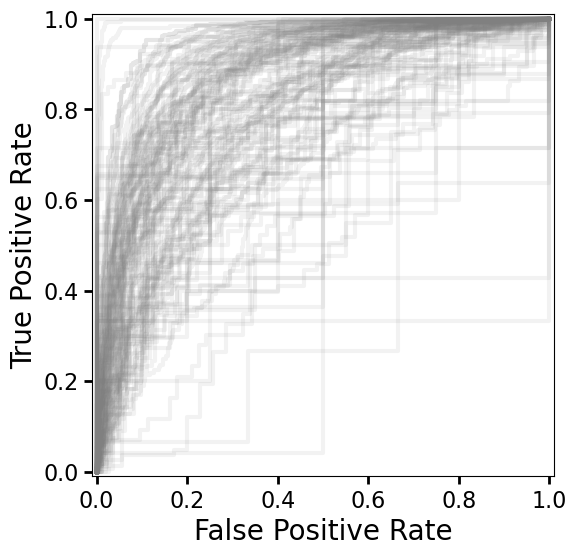

AUC: 0.8029822370132408
PR AUC: 0.8002111266529713


In [16]:
fig, (ax1) = plt.subplots(1, 1, figsize=(6, 6))

auc = []
pr_auc = []

for t, d_min in zip(true_list, d_min_list):
    if t == 0 or t == -1:
        continue

    y_true = t
    y_score = -1 * np.array(d_min) # sklearn takes items that are above, not below the selection

    # print(y_true, y_score)
    fpr, tpr, _ = sklearn.metrics.roc_curve(y_true, y_score)
    roc_display = sklearn.metrics.RocCurveDisplay(fpr=fpr, tpr=tpr)

    prec, recall, _ = sklearn.metrics.precision_recall_curve(y_true, y_score)
    pr_display = sklearn.metrics.PrecisionRecallDisplay(precision=prec, recall=recall)

    roc_display.plot(ax=ax1, curve_kwargs={"alpha":0.1, "color":"grey"})
    # pr_display.plot(ax=ax2, alpha=0.2)

    auc.append(sklearn.metrics.roc_auc_score(y_true, y_score))
    pr_auc.append(sklearn.metrics.auc(recall, prec))

fig.savefig("../plots/AUC_curve.pdf", bbox_inches='tight')
plt.show()
print("AUC:", np.nanmean(auc))
print("PR AUC:", np.nanmean(pr_auc))

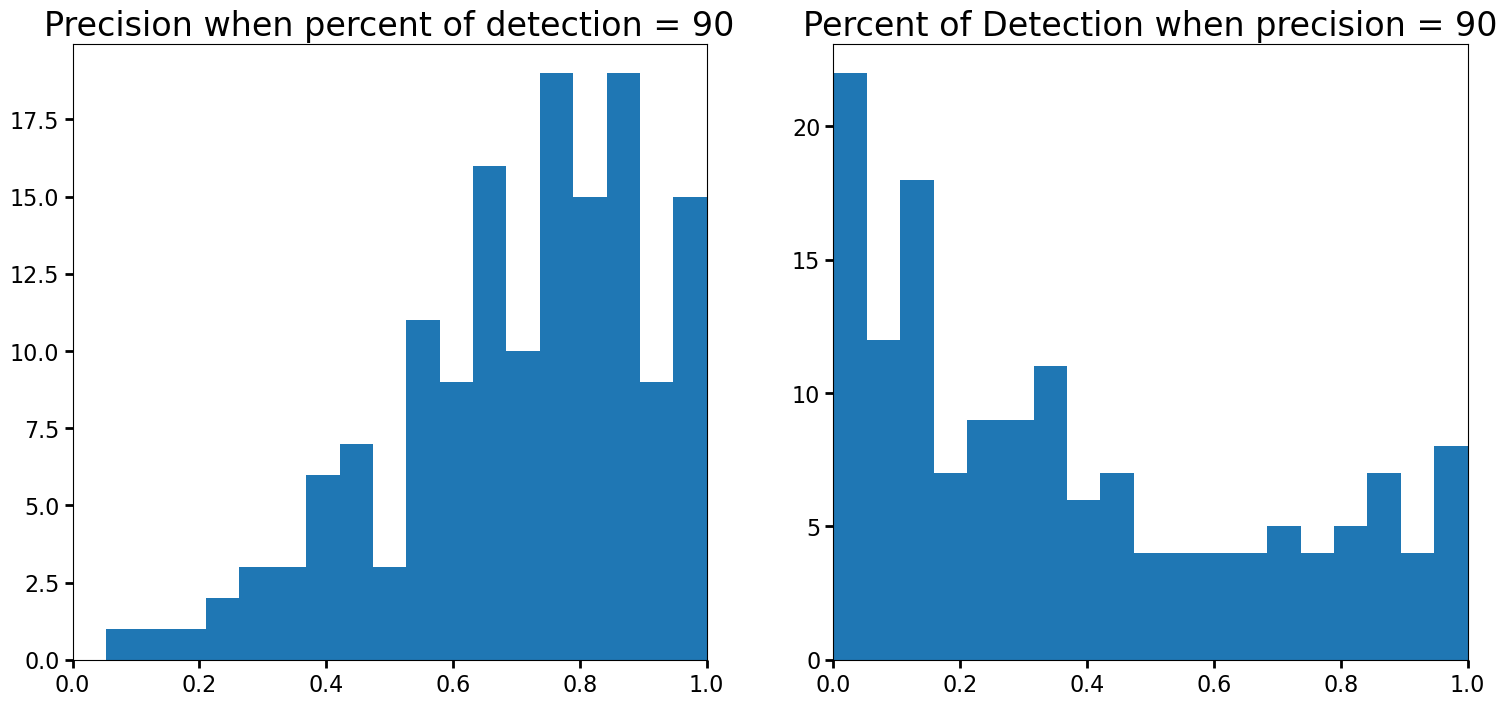

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

width = 20
bins = np.linspace(0, 1, width)

ax1.hist(df_90["Precision (90% Percent)"]/100, bins = bins)
ax1.hist(df_90[df_90["Precision (90% Percent)"] == 0]["Precision (90% Percent)"]/100, bins = bins, color = "grey")
ax1.set_title("Precision when percent of detection = 90")
ax1.set_xlim(0, 1)

ax2.hist(df_90["Percent (90% Precision)"]/100, bins = bins)
ax2.hist(df_90[df_90["Percent (90% Precision)"] == 0]["Percent (90% Precision)"]/100, bins = bins, color = "grey")
ax2.set_title("Percent of Detection when precision = 90")
ax2.set_xlim(0, 1)

fig.savefig("../plots/family_histogram.pdf")

In [18]:
df_90[df_90["Precision (90% Percent)"] == 0]["Precision (90% Percent)"]

Series([], Name: Precision (90% Percent), dtype: float64)

Text(0.5, 1.0, 'Ratio between d(90) and d Nesvorny')

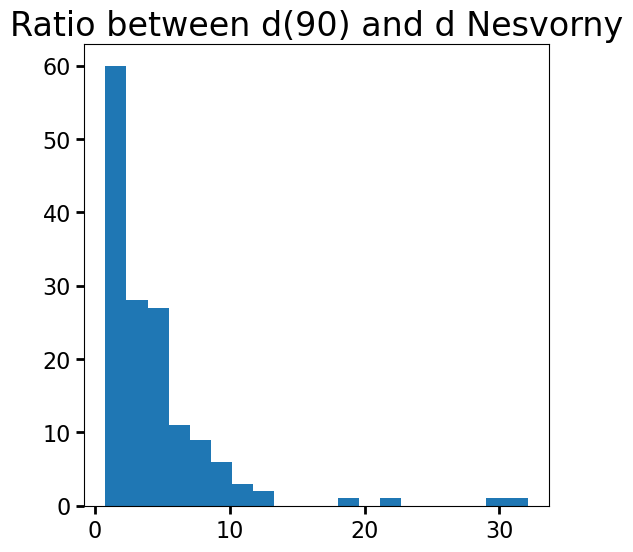

In [19]:
ratio = np.array(fixed_percent_detected_d)/np.array(d_nes_list)
plt.hist(ratio, bins = 20)
plt.title("Ratio between d(90) and d Nesvorny")

/tmp/ipykernel_335971/944927906.py:1: RuntimeWarning: invalid value encountered in divide
  precision = np.array(detected_family_list) / np.array(detected_asteroids_list) * 100
/tmp/ipykernel_335971/944927906.py:2: RuntimeWarning: invalid value encountered in divide
  percent_detected = np.array(detected_family_list) / np.array(total_family_list) * 100


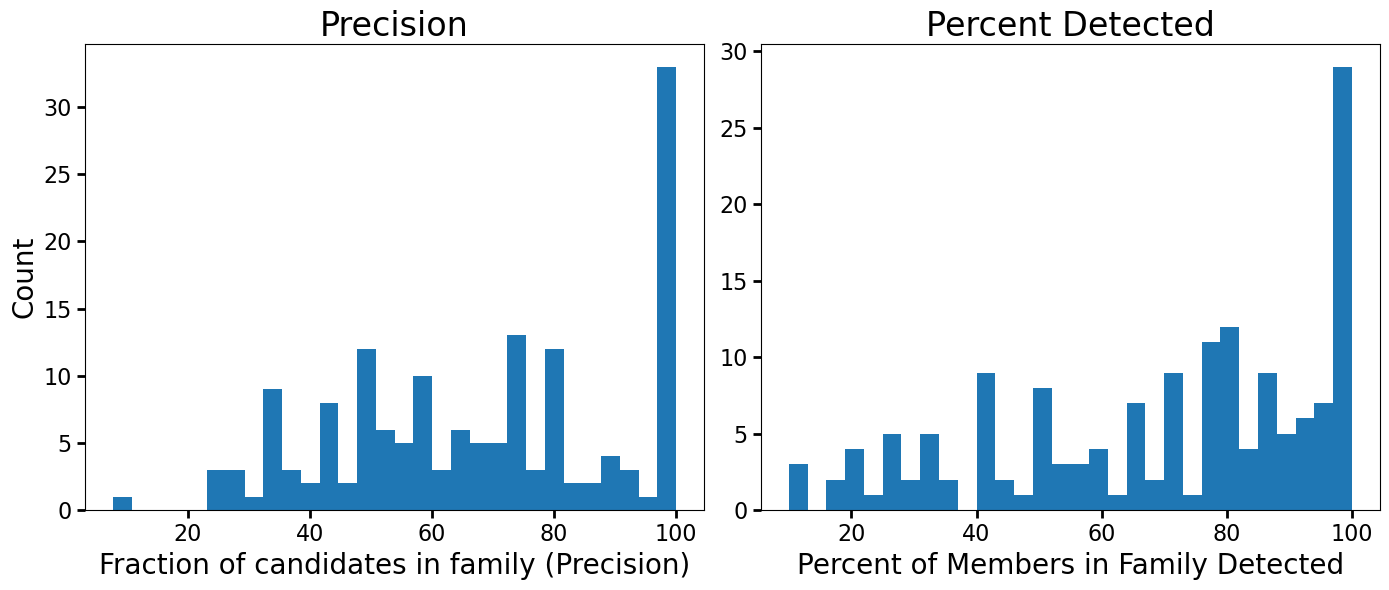

In [ ]:
precision = np.array(detected_family_list) / np.array(detected_asteroids_list) * 100
percent_detected = np.array(detected_family_list) / np.array(total_family_list) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(precision, bins = 30)
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Fraction of candidates in family (Precision)")
axes[0].set_title("Precision")

axes[1].hist(percent_detected, bins = 30)
axes[1].set_xlabel("Percent of Members in Family Detected")
axes[1].set_title("Percent Detected")

plt.tight_layout()
plt.savefig("../plots/Precision_and_Percent_detected.pdf")
plt.show()